# 02 - Policy Gradients

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## A Different Way to Choose: Learning a Policy Directly

Recall the **Policy Network** from `deep_learning_primer/02-value-and-policy-networks.ipynb`: same network body as a value network, but its output head is logits through a **Softmax**, producing a probability distribution over actions. `01-mdps-and-value-based-learning.ipynb` never actually used one of these - it learned Q-values (from a table, then a network) and always chose the action with the highest one; the policy was *implicit*, derived from values after the fact. This notebook trains a Policy Network directly: no Q-values anywhere, just probabilities, nudged by how good the reward turned out to be.

## Simplifying to the First Pick

To keep the update itself easy to follow, we isolate just the *first* decision from `01`'s draft - not because policy gradient can't handle the full 2-step draft (it can, using the total episode return, the same way Q-learning's target used $\gamma \max_{a'} Q(s',a')$ to reach across steps), but because `01` already covered multi-step credit assignment, and mixing that with a new update rule at the same time would bury the new idea. So: one decision, three possible teams to draft first, and a reward for that pick equal to the best achievable *total* score from `01`'s hand-worked values ($\approx 15.5$ for picking A or B first, $\approx 10.5$ for picking C first), plus a little random noise so the signal looks like a real, noisy reward instead of a fixed lookup table.

In [2]:
REWARD_MEANS = {'A': 15.5, 'B': 15.5, 'C': 10.5}
ACTIONS = list(REWARD_MEANS.keys())

def sample_reward(action):
    return REWARD_MEANS[action] + np.random.normal(0, 1.0)

## Policy Network and the Softmax Gradient

To train the policy, we need the gradient of the network's log-probability for the action it actually took, with respect to its logits. That gradient turns out to be one of the cleanest results in deep learning:

$$ \nabla_{\text{logits}} \big[-\log \pi(a)\big] = \pi - \text{onehot}(a) $$

which is *exactly* the same gradient shape as an ordinary classification cross-entropy loss - the one hiding inside `cv_primer/03`'s `MLPClassifier` the whole time. Policy gradient scales that same gradient by how much better (or worse) than expected the reward turned out to be, using a **Baseline** (here, a running average reward) as the reference point:

$$ \text{Loss} = -(\text{reward} - \text{baseline}) \cdot \log \pi(a) $$

If the action did better than the baseline, minimizing this loss pushes its probability *up* - an ordinary classification update, pulled toward the action you took. If it did worse, the same gradient (now negatively scaled) pushes probability *down* instead. There's no separate "policy gradient algorithm" to learn from scratch - it's a classification loss with a reward-shaped scaling factor bolted on.

In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z)

# our simplified version has no state to condition on - this is the simplest possible
# bandit case, a single fixed dummy input. A real scouting policy network's input would
# instead be the candidate teams' feature vectors, exactly like notebook 01's Q-network,
# so it could choose differently depending on which teams are actually available.
dummy_input = np.array([[1.0]])

W1_p = np.random.randn(4, 1) * 0.5
b1_p = np.zeros((4, 1))
W2_p = np.random.randn(3, 4) * 0.5   # Classification Head: 3 logits, one per action
b2_p = np.zeros((3, 1))

def policy_forward(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = relu(z1)
    logits = W2 @ a1 + b2
    probs = softmax(logits)
    return z1, a1, logits, probs

## Training the Policy

In [4]:
learning_rate = 0.05
n_episodes = 4000
baseline = 0.0
baseline_rate = 0.05   # how fast the running-average baseline updates

prob_history = {a: [] for a in ACTIONS}
reward_history = []

for episode in range(n_episodes):
    z1, a1, logits, probs = policy_forward(dummy_input, W1_p, b1_p, W2_p, b2_p)

    action_idx = np.random.choice(len(ACTIONS), p=probs.flatten())
    action = ACTIONS[action_idx]
    reward = sample_reward(action)
    reward_history.append(reward)

    advantage = reward - baseline
    onehot = np.zeros((3, 1))
    onehot[action_idx, 0] = 1.0

    # dLoss/dlogits for Loss = -(reward - baseline) * log(prob of the action taken)
    d_logits = advantage * (probs - onehot)

    d_W2 = d_logits @ a1.T
    d_b2 = d_logits
    d_a1 = W2_p.T @ d_logits
    d_z1 = d_a1 * relu_derivative(z1)
    d_W1 = d_z1 @ dummy_input.T
    d_b1 = d_z1

    W1_p -= learning_rate * d_W1
    b1_p -= learning_rate * d_b1
    W2_p -= learning_rate * d_W2
    b2_p -= learning_rate * d_b2

    baseline += baseline_rate * (reward - baseline)

    _, _, _, current_probs = policy_forward(dummy_input, W1_p, b1_p, W2_p, b2_p)
    for i, a in enumerate(ACTIONS):
        prob_history[a].append(current_probs[i, 0])

print("Final action probabilities:")
_, _, _, final_probs = policy_forward(dummy_input, W1_p, b1_p, W2_p, b2_p)
for a, p in zip(ACTIONS, final_probs.flatten()):
    print(f"  pi({a}) = {p:.3f}")
print(f"(sums to {final_probs.sum():.3f})")

Final action probabilities:
  pi(A) = 0.997
  pi(B) = 0.002
  pi(C) = 0.000
(sums to 1.000)


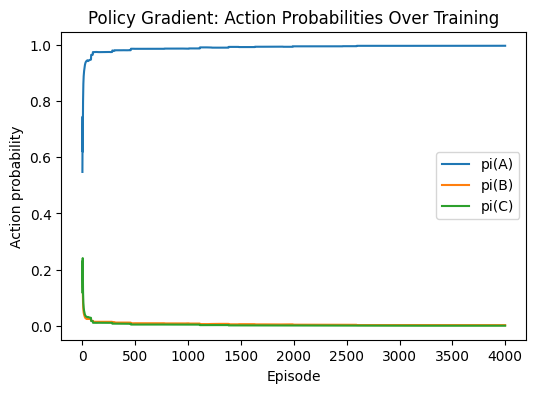

In [5]:
plt.figure(figsize=(6, 4))
for a in ACTIONS:
    plt.plot(prob_history[a], label=f'pi({a})')
plt.xlabel('Episode')
plt.ylabel('Action probability')
plt.title('Policy Gradient: Action Probabilities Over Training')
plt.legend()
plt.show()

Starting from a roughly uniform guess across all three actions, the policy should shift most of its probability onto A and B (the two first-picks with the highest expected reward, $\approx 15.5$ each) and away from C ($\approx 10.5$) - purely from sampled, noisy rewards, with no Q-value or table involved anywhere in this notebook.

## The Real Difference Isn't the Architecture

Value-based methods (`01`, Q-learning) and Policy Gradient methods (this notebook) are the two core families of deep RL. Modern systems often combine both in an **Actor-Critic** architecture: a value network "critiques" how good the policy's chosen actions turned out to be - replacing the simple running-average baseline used here with something that actually depends on the state - while a policy network keeps choosing the actions. Whether this team's scouting agent is better served by Q-learning alone, policy gradient alone, or a combined Actor-Critic setup depends on something this primer can't answer from the curriculum alone: how much real scouting data (matches, seasons) will actually be available to train on. Actor-Critic setups are generally more sample-hungry but more flexible; plain Q-learning, like notebook `01`, tends to be the more forgiving starting point on a smaller dataset.

## Try It Yourself

Add a 4th action to `REWARD_MEANS` with a mean reward between B/A's and C's, e.g. `'D': 13.0`, and reduce the reward noise from `np.random.normal(0, 1.0)` to `np.random.normal(0, 0.3)` in `sample_reward`. You'll need to resize `W2_p` and `b2_p` to output 4 logits instead of 3 (`W2_p = np.random.randn(4, 4) * 0.5`, `b2_p = np.zeros((4, 1))`) and update `ACTIONS`.

Retrain, and confirm: **the combined probability on A and B together is much larger than the combined probability on C and D together.** Don't expect much more precision than that. Once training pushes a policy to strongly favor one action, the actions it didn't pick get very little further gradient signal to sort out *their* relative order - so a single training run reliably tells you the policy avoided the bad options, but not reliably whether it correctly ranked C below D or vice versa. That's not a bug in what you built; it's a genuine limitation of plain policy gradient with noisy, single-sample rewards, and it's exactly the kind of variance an Actor-Critic setup's value-network baseline (mentioned above) is built to reduce.

In [6]:
# TODO: add a 4th action 'D' with REWARD_MEANS['D'] = 13.0, reduce sample_reward's noise
# to np.random.normal(0, 0.3), resize the output layer to 4 logits, retrain, and check
# that P(A) + P(B) clearly beats P(C) + P(D)


## Resources

- [OpenAI Spinning Up: Vanilla Policy Gradient](https://spinningup.openai.com/en/latest/algorithms/vpg.html) - a code-adjacent walkthrough of the same policy-gradient update derived above (instructional).
- Williams, R.J. (1992). "Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning." *Machine Learning*, 8. The original REINFORCE paper this notebook's update rule comes from (paper).
- [Sutton & Barto: *Reinforcement Learning: An Introduction*](http://incompleteideas.net/book/the-book.html), Chapter 13 - the formal derivation of the policy gradient theorem, for the full proof behind the gradient this notebook used directly (textbook).